In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
input = pd.read_csv(r'./Dataset/extracted_dataset/non-multisegment/non-multisegment_input.csv')
src = pd.read_csv(r'./Dataset/extracted_dataset/non-multisegment/non-multisegment_output.csv')

In [3]:
input.head()

,filename,Event,EventTAG,LAT,LON,DEP,LEN_f,WID,Mw,Mo,...,HR-GPS-Data,Hr-GPS-Data,InSAR-Data,Other-Data,SAT-Data,SPOT-Data,hr-GPS-Data,inSAR-Data,level-Data,tril-Data
0,s1906SANFRA01SONG.fsp,San Francisco (Calif.),s1906SANFRA01SONG,37.78,-122.51,10.0,480.0,12.0,7.91,8.150000e+20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,s1906SANFRA01THAT.fsp,San Francisco (Calif.),s1906SANFRA01THAT,37.78,-122.51,10.0,480.0,10.0,7.91,8.120000e+20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,s1923KANTOJ01KOBA.fsp,Kanto (Japan),s1923KANTOJ01KOBA,35.40,139.20,14.6,130.0,70.0,8.08,1.460000e+21,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,s1923KANTOJ01WALD.fsp,Kanto (Japan),s1923KANTOJ01WALD,35.40,139.20,14.6,130.0,70.0,7.95,9.330000e+20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,s1944TONANK01ICHI.fsp,Tonankai (Japan),s1944TONANK01ICHI,33.77,135.96,30.0,220.0,140.0,8.04,1.310000e+21,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Total unique shapes: 271
Most common shape: 3x3 (Count: 24)
Shape with most cells: 3663x5297 (Total: 19402911 cells)
Average grid size: 620181.2 cells


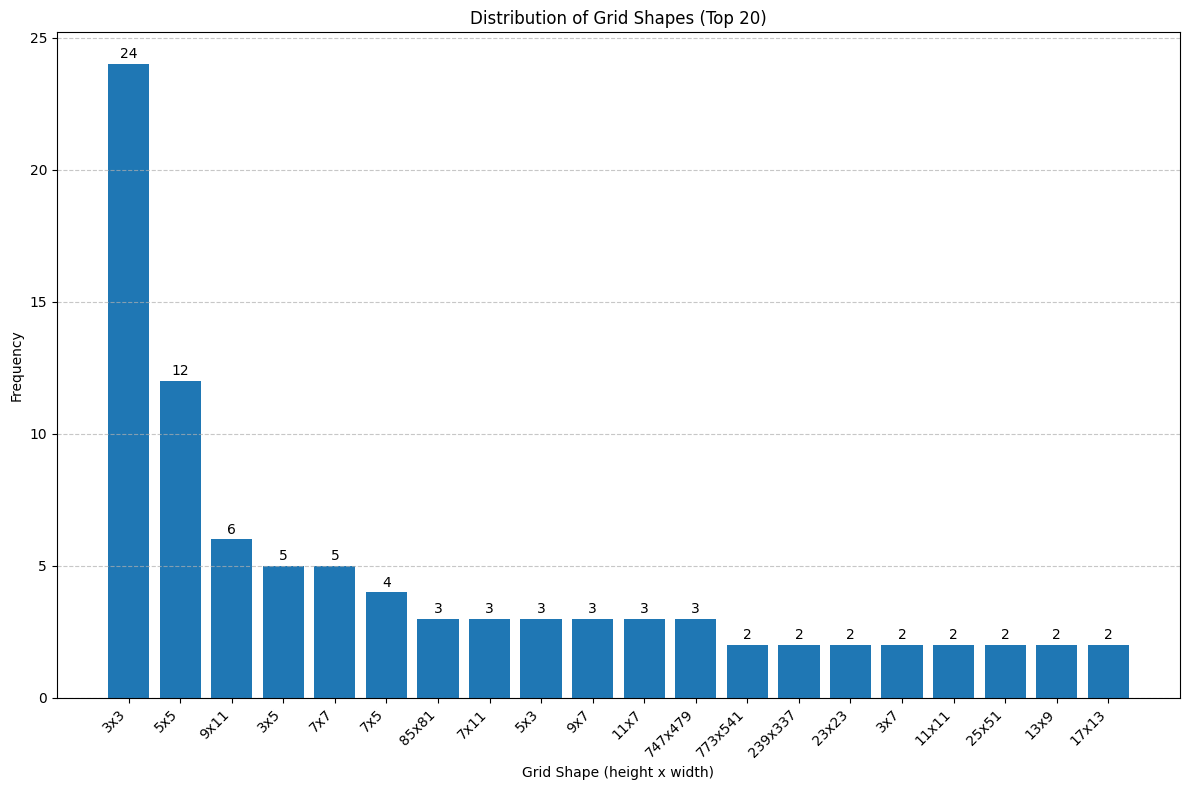

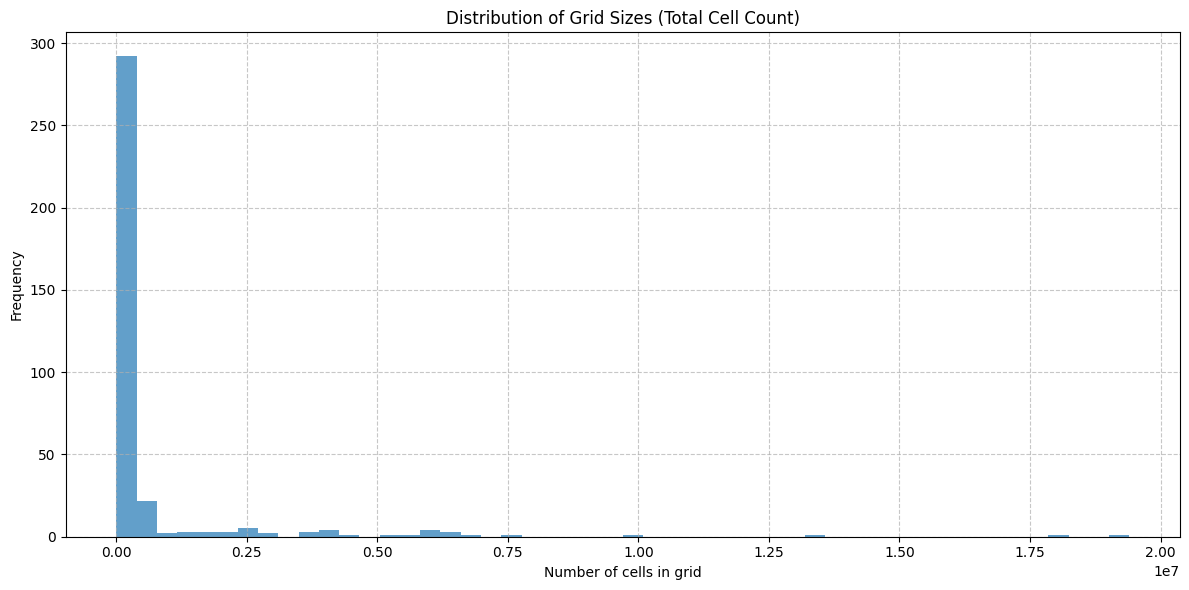

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from collections import Counter

# To store grid shapes 
grid_shapes = []
c=0

for i in src['filename'].unique():
    # Step 1: Load data from CSV
    # Extract columns. Here 'ES' corresponds to the X-axis and 'NS' to the Y-axis.
    es = src[src['filename']==i]['X==EW'].values * input[input['filename']==i]['Dx'].values[0]/5
    ns = src[src['filename']==i]['Y==NS'].values * input[input['filename']==i]['Dx'].values[0]/5
    slip = src[src['filename']==i]['SLIP'].values/src[src['filename']==i]['SLIP'].max()
    # c+=1
    # print(c)

    # Step 2: Recenter coordinates so that (0,0) is the center.
    # We subtract the mean so that the data is centered.
    es_centered = es - np.mean(es)
    ns_centered = ns - np.mean(ns)

    # Step 3: Define a grid of integer-valued pixel positions.
    # Compute grid bounds using the floor/ceil to cover the whole data range.
    x_min = int(np.floor(np.min(es_centered)))
    x_max = int(np.ceil(np.max(es_centered)))
    y_min = int(np.floor(np.min(ns_centered)))
    y_max = int(np.ceil(np.max(ns_centered)))

    # Create a meshgrid with integer positions.
    grid_x, grid_y = np.meshgrid(np.arange(x_min, x_max + 1),
                                np.arange(y_min, y_max + 1))
    
    try:
        # Step 4: Interpolate slip values onto the integer grid.
        # Points is an array of the centered (x,y) coordinates.
        points = np.column_stack((es_centered, ns_centered))
        grid_slip = griddata(points, slip, (grid_x, grid_y), method='nearest', fill_value=0)
        
        # Store the shape of grid_slip
        grid_shapes.append(grid_slip.shape)
        
    except Exception as e:
        print(f"Error with {i}: {e}")
        continue

# Convert shapes to strings for better visualization
grid_shape_strs = [f"{shape[0]}x{shape[1]}" for shape in grid_shapes]

# Count occurrences of each shape
shape_counts = Counter(grid_shape_strs)

# Sort by frequency
sorted_shapes = sorted(shape_counts.items(), key=lambda x: x[1], reverse=True)

# Plot the distribution of grid shapes
plt.figure(figsize=(12, 8))
bars = plt.bar([item[0] for item in sorted_shapes[:20]], [item[1] for item in sorted_shapes[:20]])

# Add count labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{height}', ha='center', va='bottom', rotation=0)

plt.title('Distribution of Grid Shapes (Top 20)')
plt.xlabel('Grid Shape (height x width)')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Summary statistics
print(f"Total unique shapes: {len(shape_counts)}")
print(f"Most common shape: {sorted_shapes[0][0]} (Count: {sorted_shapes[0][1]})")

# Find the shape with max width, height and total cells
grid_sizes = [shape[0] * shape[1] for shape in grid_shapes]
max_height = max(shape[0] for shape in grid_shapes)
max_width = max(shape[1] for shape in grid_shapes)
max_size = max(grid_sizes)
max_size_shape = grid_shapes[grid_sizes.index(max_size)]

# print(f"Largest grid dimensions: {max_height}x{max_width}")
print(f"Shape with most cells: {max_size_shape[0]}x{max_size_shape[1]} (Total: {max_size} cells)")
print(f"Average grid size: {sum(grid_sizes)/len(grid_sizes):.1f} cells")

# Plot the distribution of grid sizes (total number of cells)
grid_sizes = [shape[0] * shape[1] for shape in grid_shapes]

plt.figure(figsize=(12, 6))
plt.hist(grid_sizes, bins=50, alpha=0.7)
plt.title('Distribution of Grid Sizes (Total Cell Count)')
plt.xlabel('Number of cells in grid')
plt.ylabel('Frequency')
plt.grid(linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()


In [29]:
# Find the shape with max width, height and total cells
grid_sizes = [shape[0] * shape[1] for shape in grid_shapes]
max_height = max(shape[0] for shape in grid_shapes)
max_width = max(shape[1] for shape in grid_shapes)
max_size = max(grid_sizes)
max_size_shape = grid_shapes[grid_sizes.index(max_size)]

print(f"Largest grid dimensions: {max_height}x{max_width}")
print(f"Shape with most cells: {max_size_shape[0]}x{max_size_shape[1]} (Total: {max_size} cells)")
print(f"Average grid size: {sum(grid_sizes)/len(grid_sizes):.1f} cells")


Largest grid dimensions: 5729x5297
Shape with most cells: 3663x5297 (Total: 19402911 cells)
Average grid size: 620181.2 cells


In [15]:
i='s1978MIYAGI01YAMA.fsp'
input[input['filename']==i]['Dx'].values[0]

np.float64(10.0)

In [21]:
input.columns

Index(['filename', 'Event', 'EventTAG', 'LAT', 'LON', 'DEP', 'LEN_f', 'WID',
       'Mw', 'Mo', 'STRK', 'DIP', 'RAKE', 'Htop', 'HypX', 'HypZ', 'avTr',
       'avVr', 'Nx', 'Nz', 'Fmin', 'Fmax', 'Dx', 'Dz', 'Ntw', 'Nsg', 'LEN_inv',
       'SHF', 'SVF', 'SGM-Data', 'TELE-Data', 'TRIL-Data', 'LEVEL-Data',
       'GPS-Data', 'INSAR-Data', 'SURF-Data', 'OTHER-Data', 'SGM-PHImx',
       'TELE-PHImx', 'TRIL-PHImx', 'LEVEL-PHImx', 'GPS-PHImx', 'INSAR-PHImx',
       'SURF-PHImx', 'OTHER-PHImx', 'SGM-Rmin', 'TELE-Rmin', 'TRIL-Rmin',
       'LEVEL-Rmin', 'GPS-Rmin', 'INSAR-Rmin', 'SURF-Rmin', 'OTHER-Rmin',
       'BBR-Data', 'HR-GPS-Data', 'Hr-GPS-Data', 'InSAR-Data', 'Other-Data',
       'SAT-Data', 'SPOT-Data', 'hr-GPS-Data', 'inSAR-Data', 'level-Data',
       'tril-Data'],
      dtype='object')

In [24]:
input[input['filename']==i]['Event'].values[0]

'Miyagiki (Japan)'

(550, 968)
Generated an example interpolated image with shape: (550, 968)
Generated LAT/LON images, each with shape: (550, 968)

Coordinates for pixel (row=50, col=100):
  Latitude: 38.1871
  Longitude: 142.1048


/tmp/ipykernel_748869/2592546889.py:176: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()


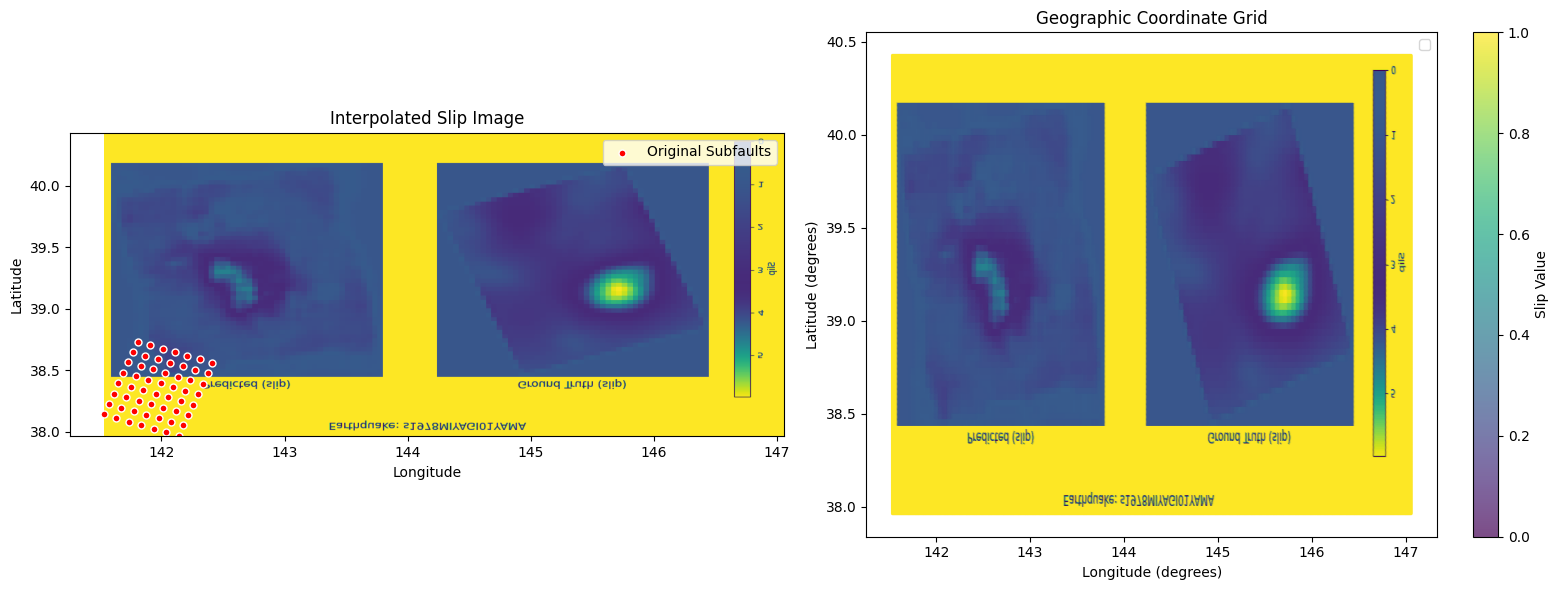

In [17]:
import numpy as np
import pandas as pd
import io
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

# =============================================================================
# 1. SETUP: Load original data and metadata from your provided text
# =============================================================================

i='s1978MIYAGI01YAMA.fsp'
src_df=src[src['filename']==i]

Dx = input[input['filename']==i]['Dx'].values[0]
# =============================================================================
# 2. FORWARD PROCESS: Generate the interpolated image (as in your example)
#    This gives us an image to work with for the reversal.
# =============================================================================

# Extract and scale coordinates
es = src_df['X==EW'].values * Dx / 5.0
ns = src_df['Y==NS'].values * Dx / 5.0
slip = src_df['SLIP'].values / src_df['SLIP'].max()

# Recenter coordinates
es_centered = es - np.mean(es)
ns_centered = ns - np.mean(ns)


epicenter_lat = input[input['filename']==i]['LAT'].values[0]
epicenter_lon = input[input['filename']==i]['LON'].values[0]

# Define the grid for interpolation
x_min = int(np.floor(np.min(es_centered)))
x_max = int(np.ceil(np.max(es_centered)))
y_min = int(np.floor(np.min(ns_centered)))
y_max = int(np.ceil(np.max(ns_centered)))

grid_x, grid_y = np.meshgrid(np.arange(x_min, x_max + 1),
                               np.arange(y_min, y_max + 1))

# Interpolate slip values onto the grid
points = np.column_stack((es_centered, ns_centered))
interpolated_slip_image = griddata(points, slip, (grid_x, grid_y), method='cubic', fill_value=0)


interpolated_slip_image = plt.imread(f"./Dataset/predicted_images_3.0/reconstructed_image_{i[:-4]}.png")
if len(interpolated_slip_image.shape) == 3:
    interpolated_slip_image = interpolated_slip_image[:, :, 0]
print(interpolated_slip_image.shape)    

print(f"Generated an example interpolated image with shape: {interpolated_slip_image.shape}")


# =============================================================================
# 3. REVERSE PROCESS: Function to get LAT/LON images from the slip image
# =============================================================================

def get_lat_lon_from_image(interpolated_image, original_x_ew, original_y_ns, 
                           epicenter_lat, epicenter_lon, Dx):
    """
    Reverses the interpolation process to generate LAT and LON images.

    Args:
        interpolated_image (np.ndarray): The 2D numpy array of the interpolated slip.
        original_x_ew (np.ndarray): The original 'X==EW' coordinates in km.
        original_y_ns (np.ndarray): The original 'Y==NS' coordinates in km.
        epicenter_lat (float): Latitude of the epicenter.
        epicenter_lon (float): Longitude of the epicenter.
        Dx (float): The inversion parameter 'Dx' in km.

    Returns:
        tuple: A tuple containing two 2D numpy arrays: (lat_grid, lon_grid).
    """

    # --- Step 1: Recalculate key parameters from the forward process ---
    # These are needed to correctly map pixel coordinates back.
    es = original_x_ew * Dx / 5.0
    ns = original_y_ns * Dx / 5.0
    mean_es = np.mean(es)
    mean_ns = np.mean(ns)
    es_centered = es - mean_es
    ns_centered = ns - mean_ns
    x_min_fwd = int(np.floor(np.min(es_centered)))
    y_min_fwd = int(np.floor(np.min(ns_centered)))
    
    # --- Step 2: Create a grid of the image's pixel coordinates ---
    height, width = interpolated_image.shape
    pixel_cols, pixel_rows = np.meshgrid(np.arange(width), np.arange(height))

    # --- Step 3: Map pixel coordinates back to the centered local grid ---
    # This reverses the creation of the grid.
    es_centered_grid = pixel_cols + x_min_fwd
    ns_centered_grid = pixel_rows + y_min_fwd

    # --- Step 4: Reverse the centering and scaling ---
    # Add the mean back to reverse the centering
    es_grid = es_centered_grid + mean_es
    ns_grid = ns_centered_grid + mean_ns
    
    # Divide by the scaling factor to get back to original km units
    x_ew_grid_km = es_grid / (Dx / 5.0)
    y_ns_grid_km = ns_grid / (Dx / 5.0)
    
    # --- Step 5: Convert local km coordinates to geographic LAT/LON degrees ---
    # The origin (0,0) of the (X==EW, Y==NS) system is the epicenter.
    km_per_deg_lat = 111.32
    km_per_deg_lon = 111.32 * np.cos(np.radians(epicenter_lat))
    
    # Calculate the offset in degrees from the epicenter
    delta_lat_grid = y_ns_grid_km / km_per_deg_lat
    delta_lon_grid = x_ew_grid_km / km_per_deg_lon
    
    # Add the offset to the epicenter's coordinates
    lat_grid = epicenter_lat + delta_lat_grid
    lon_grid = epicenter_lon + delta_lon_grid
    
    return lat_grid, lon_grid

# --- Execute the reversal function ---
lat_image, lon_image = get_lat_lon_from_image(
    interpolated_image=interpolated_slip_image,
    original_x_ew=src_df['X==EW'].values,
    original_y_ns=src_df['Y==NS'].values,
    epicenter_lat=epicenter_lat,
    epicenter_lon=epicenter_lon,
    Dx=Dx
)

print(f"Generated LAT/LON images, each with shape: {lat_image.shape}")
# =============================================================================
# 4. USAGE AND VISUALIZATION
# =============================================================================

# --- Getting the coordinates for a specific pixel ---
# For example, let's get the LAT/LON for the pixel at row=50, column=100
row, col = 50, 100
specific_lat = lat_image[row, col]
specific_lon = lon_image[row, col]
print(f"\nCoordinates for pixel (row={row}, col={col}):")
print(f"  Latitude: {specific_lat:.4f}")
print(f"  Longitude: {specific_lon:.4f}")

# --- Visualizing the resulting coordinate images ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Original Interpolated Slip Image
ax1 = axes[0]
im1 = ax1.imshow(interpolated_slip_image, origin='lower', cmap='viridis', 
                 extent=[lon_image.min(), lon_image.max(), lat_image.min(), lat_image.max()])
ax1.set_title("Interpolated Slip Image")
ax1.set_xlabel("Longitude")
ax1.set_ylabel("Latitude")
# Overlay original data points for reference
ax1.scatter(src_df['LON'], src_df['LAT'], c='red', edgecolor='white', s=25, label='Original Subfaults')
ax1.legend()

# Plot 2: Combined Latitude and Longitude Grid
ax2 = axes[1]
# Create a scatter plot using the lat/lon grids as coordinates
height, width = lat_image.shape
# Flatten the grids to create coordinate pairs
lon_flat = lon_image.flatten()
lat_flat = lat_image.flatten()
slip_flat = interpolated_slip_image.flatten()

# Create scatter plot with longitude on x-axis and latitude on y-axis
scatter = ax2.scatter(lon_flat, lat_flat, c=slip_flat, cmap='viridis', s=1, alpha=0.7)
ax2.set_title("Geographic Coordinate Grid")
ax2.set_xlabel("Longitude (degrees)")
ax2.set_ylabel("Latitude (degrees)")
fig.colorbar(scatter, ax=ax2, label="Slip Value")

# Overlay original data points for reference
# ax2.scatter(src_df['LON'], src_df['LAT'], c='red', edgecolor='white', s=25, label='Original Subfaults')
ax2.legend()

plt.tight_layout()
plt.show()

In [4]:
max_slip=src['SLIP'].max()

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
c=0
cnt=0
for i in src['filename'].unique():

    # if i[:-4] != 's2016SOLOMO01HAYE':
    #     continue
    # Step 1: Load data from CSV
    # Extract columns. Here 'ES' corresponds to the X-axis and 'NS' to the Y-axis.
    es = src[src['filename']==i]['LON'].values*111
    ns = src[src['filename']==i]['LAT'].values*111
    slip = (src[src['filename']==i]['SLIP'].values/max_slip)*100
    # print(es)
    c+=1
    print(c)

    # Step 2: Recenter coordinates so that (0,0) is the center.
    # We subtract the mean so that the data is centered.
    es_centered = es - input[input['filename']==i]['LON'].values[0]*111
    ns_centered = ns - input[input['filename']==i]['LAT'].values[0]*111

    # print(es_centered)
    # Step 3: Define a grid of integer-valued pixel positions.
    # Compute grid bounds using the floor/ceil to cover the whole data range.
    x_min = int(np.floor(np.min(es_centered)))
    x_max = int(np.ceil(np.max(es_centered)))
    y_min = int(np.floor(np.min(ns_centered)))
    y_max = int(np.ceil(np.max(ns_centered)))

    # Create a meshgrid with integer positions.
    grid_x, grid_y = np.meshgrid(np.arange(x_min, x_max + 1),
                                np.arange(y_min, y_max + 1))
    
    try:
        # Step 4: Interpolate slip values onto the integer grid.
        # Points is an array of the centered (x,y) coordinates.
        points = np.column_stack((es_centered, ns_centered))
        grid_slip = griddata(points, slip, (grid_x, grid_y), method='cubic', fill_value=0)

    except:
        print(i)
        continue


    # Optionally, you can replace NaNs (outside the convex hull of your data)
    # # For example, with zeros or using nearest neighbor interpolation:
    # grid_slip = np.where(np.isnan(grid_slip),
    #                      griddata(points, slip, (grid_x, grid_y), method='nearest'),
    #                      grid_slip)

    # plt.figure(figsize=(8, 6))
    # scatter = plt.scatter(es_centered, ns_centered, c=slip, 
    #                     cmap='viridis', s=50, alpha=0.8)
    # plt.colorbar(scatter, label='Normalized Slip')
    # plt.title("Slip Values (Scatter Plot)")
    # plt.xlabel("ES (centered)")
    # plt.ylabel("NS (centered)")
    # plt.grid(True, linestyle='--', alpha=0.7)
    # plt.show()


    # # Step 5: Visualize the image.
    # plt.figure(figsize=(8, 6))
    # plt.imshow(grid_slip, extent=(x_min, x_max, y_min, y_max),
    #         origin='lower', cmap='viridis')
    # plt.colorbar(label='Slip Intensity')
    # plt.title(f"Interpolated Slip Image (Integer Pixel Grid) for {i}")
    # plt.xlabel("ES (centered)")
    # plt.ylabel("NS (centered)")
    # plt.show()

    
    # # # Optionally, save the image.

    if(grid_slip.shape[0]>=50 or grid_slip.shape[1]>=50):
        print(i)
        cnt+=1
        plt.imsave(F"./Dataset/ALL_IMAGES_LAT_LON/interpolated_slip_image_{i}.png", grid_slip, cmap='viridis',
            vmin=np.nanmin(grid_slip), vmax=np.nanmax(grid_slip))
    
    # break

1
s1906SANFRA01SONG.fsp
2
s1906SANFRA01THAT.fsp
3
s1923KANTOJ01KOBA.fsp
4
s1944TONANK01ICHI.fsp
5
s1944TONANK01KATO.fsp
6
s1944TONANK01KIKU.fsp
7
s1944TONANK01SATA.fsp
8
s1944TONANK01TANI.fsp
9
10
s1946NANKAI01BABA.fsp
11
s1946NANKAI01SATA.fsp
12
s1946NANKAI01TANI.fsp
13
s1968HYUGAx01YAGI.fsp
14
s1968TOKACH01NAGA.fsp
15
s1978TABASI01HART.fsp
16
17
s1979PETATL01MEND.fsp
18
s1981PLAYAA01MEND.fsp
19
s1983BORAHP01MEND.fsp
20
21
s1985ZIHUAT01MEND.fsp
22
23
24
25
26
27
28
29
30
31
32
33
34
s1994SANRIK01NAGA.fsp
35
36
37
s1995COLIMA01MEND.fsp
38
39
s1995TAIWAN01MAxx.fsp
40
41
42
s1996NAZCAR01SPEN.fsp
43
44
s1998ANTARC01ANTO.fsp
45
s1998ANTARC02ANTO.fsp
46
47
48
49
s1999DUZCET01BIRG.fsp
50
s1999IZMITT01YAGI.fsp
51
s2001BHUJIN01ANTO.fsp
52
53
54
s2003TOKACH01KOKE.fsp
55
s2003TOKACH01TANI.fsp
56
s2003TOKACH01YAGI.fsp
57
s2003TOKACH01YAMA.fsp
58
59
60
61
s2006PINGTU02YENx.fsp
62
63
64
s2010ELMAYO01MEND.fsp
65
s2010HAITIx01CALA.fsp
66
67
68
s2011VANTUR01UTKU.fsp
69
s2012NICOYA01LOPE.fsp
70
s2020SA

In [ ]:
cnt

In [ ]:
slip.min()


np.float64(0.026625258799171842)

In [ ]:
slip.shape

(48,)

In [ ]:
import cv2
import numpy as np

def resize_3d_array(image_array, new_x, new_y):
    """
    Resize a 3D NumPy array along x and y dimensions while interpolating the z-dimension.
    
    Parameters:
        image_array (np.array): Input array of shape (X, Y, Z)
        new_x (int): Desired height
        new_y (int): Desired width
    
    Returns:
        np.array: Resized array of shape (new_x, new_y, Z)
    """
    X, Y, Z = image_array.shape
    resized_slices = [cv2.resize(image_array[:, :, i], (new_y, new_x), interpolation=cv2.INTER_LINEAR) for i in range(Z)]
    resized_array = np.stack(resized_slices, axis=-1)  # Stack along the Z dimension
    
    return resized_array

# Example: Create a 3D NumPy array (e.g., 50x50 with 10 channels)
original_image = np.random.rand(50, 50, 10).astype(np.float32)  # 50x50 image with 10 channels

# Define new shape
new_x, new_y = 100, 100  # Change as needed

# Resize the 3D array
resized_image = resize_3d_array(original_image, new_x, new_y)

# Output shape confirmation
print("Original shape:", original_image.shape)
print("Resized shape:", resized_image.shape)


Original shape: (50, 50, 10)
Resized shape: (100, 100, 10)


In [ ]:
!pip install scikit-image

In [2]:
import numpy as np

a = np.load(r'./Dataset/slip_arrays_inference/slip_array_s1944TONANK01ICHI.npy')

np.mean(a), np.max(a), np.std(a.flatten())

(np.float64(0.6658818026124204),
 np.float64(2.601256022852659),
 np.float64(0.6843993034981966))

In [29]:
import numpy as np
import pandas as pd
import numpy as np
from scipy.interpolate import griddata
from skimage.transform import resize

def lat_lon_convert(file_src, file_input, grid_slip):
    # Let's use some example placeholder values

    # df_truth = src[src['filename']==i]
    df_truth = file_src
    Dx = file_input['Dx'].values[0]
    es = file_src['X==EW'].values * Dx/5
    ns = file_src['Y==NS'].values * Dx/5

    slip = file_src['SLIP'].values

    
    # grid_slip = lol
    # Dx = input[input['filename']==i]['Dx'].values[0]
    # es = src[src['filename']==i]['X==EW'].values * Dx/5
    # ns = src[src['filename']==i]['Y==NS'].values * Dx/5

    mean_es= np.mean(es)
    mean_ns= np.mean(ns)
    # --- End of assumed values ---

    # Step 2: Recenter coordinates so that (0,0) is the center.
    # We subtract the mean so that the data is centered.
    es_centered = es - np.mean(es)
    ns_centered = ns - np.mean(ns)

    # Step 3: Define a grid of integer-valued pixel positions.
    # Compute grid bounds using the floor/ceil to cover the whole data range.
    x_min = int(np.floor(np.min(es_centered)))
    x_max = int(np.ceil(np.max(es_centered)))
    y_min = int(np.floor(np.min(ns_centered)))
    y_max = int(np.ceil(np.max(ns_centered)))

    # Step 1: Recreate the grid of centered coordinates from pixel indices.
    grid_x_centered, grid_y_centered = np.meshgrid(
        np.arange(x_min, x_max + 1),
        np.arange(y_min, y_max + 1)
    )

    points = np.column_stack((es_centered, ns_centered))
    grid_slip_size = griddata(points, slip, (grid_x_centered, grid_y_centered), method='cubic')

    # Reshape grid_slip to match the shape of grid_slip_size
    # grid_slip_size has the shape from the griddata interpolation
    # We need to reshape grid_slip to have the same dimensions
    grid_slip = resize(grid_slip, grid_slip_size.shape,order=3, mode='constant', anti_aliasing=True)



    # Step 2: Reverse the centering by adding the mean back.
    es_grid = grid_x_centered + mean_es
    ns_grid = grid_y_centered + mean_ns

    # Step 3: Reverse the scaling to get the final coordinate grids.
    X_EW_grid = es_grid * (5 / Dx)
    Y_NS_grid = ns_grid * (5 / Dx)



    # --- Process and combine the data for all pixels ---

    # Flatten the 2D grid arrays into 1D arrays.
    # This uses your 'grid_slip' variable.
    x_coords_flat = X_EW_grid.flatten()
    y_coords_flat = Y_NS_grid.flatten()
    slip_values_flat = grid_slip.flatten()

    # Create a Pandas DataFrame to hold the reconstructed data for every pixel.
    df_all_pixels = pd.DataFrame({
        'X_EW': x_coords_flat,
        'Y_NS': y_coords_flat,
        'Interpolated_Slip': slip_values_flat
    })


    # # Display the shape and first few rows to verify the result for the current file.
    # print(f"--- Reconstructed data for file  ---")
    # print(f"DataFrame Shape (rows, columns): {df_all_pixels.shape}")
    # print(df_all_pixels.head())



    # --- Remove rows where 'Interpolated_Slip' is NaN ---
    df_cleaned = df_all_pixels.dropna(subset=['Interpolated_Slip'])


    # print("\n--- DataFrame after removing NaNs ---")
    # print(df_cleaned)
    # print(f"\nShape after: {df_cleaned.shape}")
    # Optionally, you can now save this complete dataset to a file.

    # Assume 'df_cleaned' is your DataFrame from the previous step.
    # It contains the valid, non-NaN grid points from your interpolation.

    # Points from your interpolated grid
    grid_points = df_cleaned[['X_EW', 'Y_NS']].values
    # Slip values corresponding to those grid points
    grid_slip_values = df_cleaned['Interpolated_Slip'].values

    # The locations where you want to sample your grid (the ground truth locations)
    truth_locations = df_truth[['X==EW', 'Y==NS']].values

    # Use griddata to find the interpolated slip values AT the ground truth locations
    # 'nearest' is a good method here to find the value of the closest grid cell.
    slip_at_truth_locations = griddata(grid_points, grid_slip_values, truth_locations, method='nearest')

    # Add these sampled values to your ground truth DataFrame for comparison
    df_truth.loc[:,'Interpolated_SLIP'] = slip_at_truth_locations


    # Assume 'df_truth' and 'df_cleaned' are already defined in your script.
    # df_truth: Contains the ground truth data linking X/Y to LAT/LON.
    # df_cleaned: Your DataFrame of grid points with X_EW, Y_NS, and slip values.

    # --- Step 1: Prepare the data for interpolation from df_truth ---

    # These are the known coordinate points from your ground truth data.
    points_xy = df_truth[['X==EW', 'Y==NS']].values

    # These are the values we want to interpolate (LAT and LON).
    values_lat = df_truth['LAT'].values
    values_lon = df_truth['LON'].values

    # --- Step 2: Define the points where you want to find LAT and LON ---

    # These are all the pixel coordinates from your cleaned grid.
    points_to_convert = df_cleaned[['X_EW', 'Y_NS']].values

    # --- Step 3: Perform the interpolation for LAT and LON separately ---

    # Interpolate to find the LAT for each point in df_cleaned.
    # 'linear' is a robust method for this kind of spatial conversion.
    lat_interp = griddata(points_xy, values_lat, points_to_convert, method='cubic')

    # Interpolate to find the LON for each point in df_cleaned.
    lon_interp = griddata(points_xy, values_lon, points_to_convert, method='cubic')


    # --- Step 4: Add the new LAT and LON values to your DataFrame ---

    # Create a copy to avoid modifying the original DataFrame in place.
    df_final = df_cleaned.copy()

    # Add the newly calculated LAT and LON as new columns.
    df_final['LAT'] = lat_interp
    df_final['LON'] = lon_interp

    # # --- Display the final result ---
    # print("--- Final DataFrame with LAT and LON for all pixels ---")
    # print(df_final.head(10))
    return df_final.dropna(subset=['LAT', 'LON'])

filename = "s1944TONANK01ICHI.fsp"
grid_slip = np.load(fr"Dataset/slip_arrays_inference/slip_array_{filename[:-4]}.npy")

df_final_ = lat_lon_convert(src[src['filename']==filename], input[input['filename']==filename], grid_slip)

/tmp/ipykernel_641419/608090146.py:114: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_truth.loc[:,'Interpolated_SLIP'] = slip_at_truth_locations


In [30]:
df_final_

,X_EW,Y_NS,Interpolated_Slip,LAT,LON
2093,42.73144,-95.851443,0.053815,32.907434,136.422617
2094,42.98144,-95.851443,0.054129,32.907434,136.425323
2095,43.23144,-95.851443,0.054502,32.907434,136.428029
3010,42.73144,-95.601443,0.058932,32.909683,136.422616
3011,42.98144,-95.601443,0.059278,32.909683,136.425322
...,...,...,...,...,...
759015,141.98144,110.398557,0.030450,34.763515,137.497076
759016,142.23144,110.398557,0.029431,34.763514,137.499783
759931,141.73144,110.648557,0.028479,34.765766,137.494369
759932,141.98144,110.648557,0.027551,34.765765,137.497076


In [16]:
src['SLIP'].max()   

np.float64(70.3156)

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from collections import Counter
from skimage.transform import resize



def lat_lon_convert_combined(file_src, file_input, grid_slip):
    # Let's use some example placeholder values

    # df_truth = src[src['filename']==i]
    df_truth = file_src
    Dx = file_input['Dx'].values[0]
    Dz = file_input['Dz'].values[0]
    es = file_src['X==EW'].values * Dx/5
    ns = file_src['Y==NS'].values * Dx/5

    slip = file_src['SLIP'].values

    
    # grid_slip = lol
    # Dx = input[input['filename']==i]['Dx'].values[0]
    # es = src[src['filename']==i]['X==EW'].values * Dx/5
    # ns = src[src['filename']==i]['Y==NS'].values * Dx/5

    mean_es= np.mean(es)
    mean_ns= np.mean(ns)
    # --- End of assumed values ---

    # Step 2: Recenter coordinates so that (0,0) is the center.
    # We subtract the mean so that the data is centered.
    es_centered = es - np.mean(es)
    ns_centered = ns - np.mean(ns)

    # Step 3: Define a grid of integer-valued pixel positions.
    # Compute grid bounds using the floor/ceil to cover the whole data range.
    x_min = int(np.floor(np.min(es_centered)))
    x_max = int(np.ceil(np.max(es_centered)))
    y_min = int(np.floor(np.min(ns_centered)))
    y_max = int(np.ceil(np.max(ns_centered)))

    # Step 1: Recreate the grid of centered coordinates from pixel indices.
    grid_x_centered, grid_y_centered = np.meshgrid(
        np.arange(x_min, x_max + 1),
        np.arange(y_min, y_max + 1)
    )

    points = np.column_stack((es_centered, ns_centered))
    grid_slip_size = griddata(points, slip, (grid_x_centered, grid_y_centered), method='cubic')

    # Reshape grid_slip to match the shape of grid_slip_size
    # grid_slip_size has the shape from the griddata interpolation
    # We need to reshape grid_slip to have the same dimensions
    grid_slip = resize(grid_slip, grid_slip_size.shape,order=3, mode='constant', anti_aliasing=True)

    # Step 2: Reverse the centering by adding the mean back.
    es_grid = grid_x_centered + mean_es
    ns_grid = grid_y_centered + mean_ns

    # Step 3: Reverse the scaling to get the final coordinate grids.
    X_EW_grid = es_grid * (5 / Dx)
    Y_NS_grid = ns_grid * (5 / Dx)



    # --- Process and combine the data for all pixels ---

    # Flatten the 2D grid arrays into 1D arrays.
    # This uses your 'grid_slip' variable.
    x_coords_flat = X_EW_grid.flatten()
    y_coords_flat = Y_NS_grid.flatten()
    slip_values_flat = grid_slip.flatten()

    # Create a Pandas DataFrame to hold the reconstructed data for every pixel.
    df_all_pixels = pd.DataFrame({
        'X_EW': x_coords_flat,
        'Y_NS': y_coords_flat,
        'Interpolated_Slip': slip_values_flat*src['SLIP'].values.max()/Dz
    })


    # # Display the shape and first few rows to verify the result for the current file.
    # print(f"--- Reconstructed data for file  ---")
    # print(f"DataFrame Shape (rows, columns): {df_all_pixels.shape}")
    # print(df_all_pixels.head())



    # --- Remove rows where 'Interpolated_Slip' is NaN ---
    df_cleaned = df_all_pixels.dropna(subset=['Interpolated_Slip'])


    # print("\n--- DataFrame after removing NaNs ---")
    # print(df_cleaned)
    # print(f"\nShape after: {df_cleaned.shape}")
    # Optionally, you can now save this complete dataset to a file.

    # Assume 'df_cleaned' is your DataFrame from the previous step.
    # It contains the valid, non-NaN grid points from your interpolation.

    # Points from your interpolated grid
    grid_points = df_cleaned[['X_EW', 'Y_NS']].values
    # Slip values corresponding to those grid points
    grid_slip_values = df_cleaned['Interpolated_Slip'].values

    # The locations where you want to sample your grid (the ground truth locations)
    truth_locations = df_truth[['X==EW', 'Y==NS']].values

    # Use griddata to find the interpolated slip values AT the ground truth locations
    # 'nearest' is a good method here to find the value of the closest grid cell.
    slip_at_truth_locations = griddata(grid_points, grid_slip_values, truth_locations, method='nearest')

    # Add these sampled values to your ground truth DataFrame for comparison
    df_truth.loc[:,'Interpolated_SLIP'] = slip_at_truth_locations


    # Assume 'df_truth' and 'df_cleaned' are already defined in your script.
    # df_truth: Contains the ground truth data linking X/Y to LAT/LON.
    # df_cleaned: Your DataFrame of grid points with X_EW, Y_NS, and slip values.

    # --- Step 1: Prepare the data for interpolation from df_truth ---

    # These are the known coordinate points from your ground truth data.
    points_xy = df_truth[['X==EW', 'Y==NS']].values

    # These are the values we want to interpolate (LAT and LON).
    values_lat = df_truth['LAT'].values
    values_lon = df_truth['LON'].values

    # --- Step 2: Define the points where you want to find LAT and LON ---

    # These are all the pixel coordinates from your cleaned grid.
    points_to_convert = df_cleaned[['X_EW', 'Y_NS']].values

    # --- Step 3: Perform the interpolation for LAT and LON separately ---

    # Interpolate to find the LAT for each point in df_cleaned.
    # 'linear' is a robust method for this kind of spatial conversion.
    lat_interp = griddata(points_xy, values_lat, points_to_convert, method='cubic')

    # Interpolate to find the LON for each point in df_cleaned.
    lon_interp = griddata(points_xy, values_lon, points_to_convert, method='cubic')


    # --- Step 4: Add the new LAT and LON values to your DataFrame ---

    # Create a copy to avoid modifying the original DataFrame in place.
    df_final = df_cleaned.copy()

    # Add the newly calculated LAT and LON as new columns.
    df_final['LAT'] = lat_interp
    df_final['LON'] = lon_interp

    # --- NEW: Add ground truth slip interpolation ---
    # Interpolate ground truth slip values onto the same grid points
    ground_truth_slip_values = df_truth['SLIP'].values
    ground_truth_slip_interp = griddata(points_xy, ground_truth_slip_values, points_to_convert, method='cubic')
    
    # Add ground truth slip as a new column
    df_final['Ground_Truth_Slip'] = ground_truth_slip_interp

    # # --- Display the final result ---
    # print("--- Final DataFrame with LAT and LON for all pixels ---")
    # print(df_final.head(10))
    return df_final.dropna(subset=['LAT', 'LON'])
    # return df_final

filename = "s2011TOHOKU01LAYx.fsp"
grid_slip = np.load(fr"Dataset/slip_arrays_inference_3.0/slip_array_{filename[:-4]}.npy")

df_final_ = lat_lon_convert_combined(src[src['filename']==filename], input[input['filename']==filename], grid_slip)


/tmp/ipykernel_708554/1367678616.py:116: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_truth.loc[:,'Interpolated_SLIP'] = slip_at_truth_locations


In [23]:
df_final_

,X_EW,Y_NS,Interpolated_Slip,LAT,LON,Ground_Truth_Slip
1857,7.257868,-218.543677,0.448700,36.180260,142.998005,22.252956
3053,6.507868,-218.293677,0.494978,36.182509,142.989426,21.768580
3054,6.757868,-218.293677,0.491615,36.182510,142.992286,21.968053
3055,7.007868,-218.293677,0.487366,36.182510,142.995146,22.167797
3056,7.257868,-218.293677,0.482149,36.182510,142.998006,22.368641
...,...,...,...,...,...,...
1918940,-22.242132,181.206323,0.411347,39.777692,142.660496,1.895979
1918941,-21.992132,181.206323,0.422579,39.777692,142.663357,1.889457
1918942,-21.742132,181.206323,0.433627,39.777691,142.666219,1.883008
1918943,-21.492132,181.206323,0.444527,39.777691,142.669081,1.876489


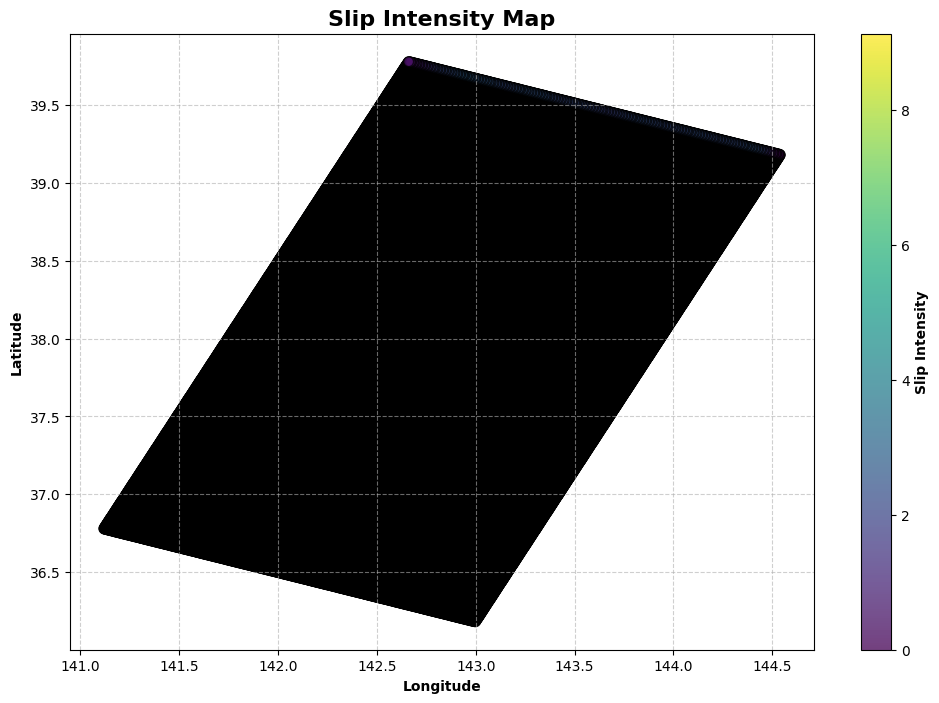

In [24]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

def plot_slip_intensity(df):
    """
    Generates a scatter plot of slip intensity at given latitude and longitude coordinates.

    Args:
        df (pd.DataFrame): A DataFrame containing 'LAT', 'LON', and 'Interpolated_Slip' columns.
    """
    if not all(col in df.columns for col in ['LAT', 'LON', 'Interpolated_Slip']):
        print("Error: DataFrame must contain 'LAT', 'LON', and 'Interpolated_Slip' columns.")
        return

    fig, ax = plt.subplots(figsize=(12, 8))

    # Create a scatter plot with color mapped to slip intensity
    scatter = ax.scatter(
        df['LON'],
        df['LAT'],
        c=df['Interpolated_Slip'],
        cmap='viridis',  # 'viridis', 'plasma', 'inferno', or 'magma' are good choices
        s=50,            # Marker size
        edgecolor='k',   # Marker edge color
        alpha=0.75       # Marker transparency
    )

    # Set labels and title for clarity
    ax.set_xlabel('Longitude', fontweight='bold')
    ax.set_ylabel('Latitude', fontweight='bold')
    ax.set_title('Slip Intensity Map', fontsize=16, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.6)

    # Add a color bar to serve as a legend for slip intensity
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Slip Intensity', fontweight='bold')

    plt.show()

# --- Example Usage ---
# After you have generated your DataFrame:
# df_final_ = lat_lon_convert_combined(src[src['filename']==filename], input[input['filename']==filename], grid_slip)

# You would then call the plotting function like this:
plot_slip_intensity(df_final_)

# As a demonstration, here is some sample data in the expected format:

# To run this example, uncomment the line below:
# plot_slip_intensity(sample_data)


# GLOBAL EARTHQUAKE DISTRIBUTION

In [ ]:
!pip install cartopy

Map has been saved as 'publication_earthquake_map.png' and 'publication_earthquake_map.pdf'


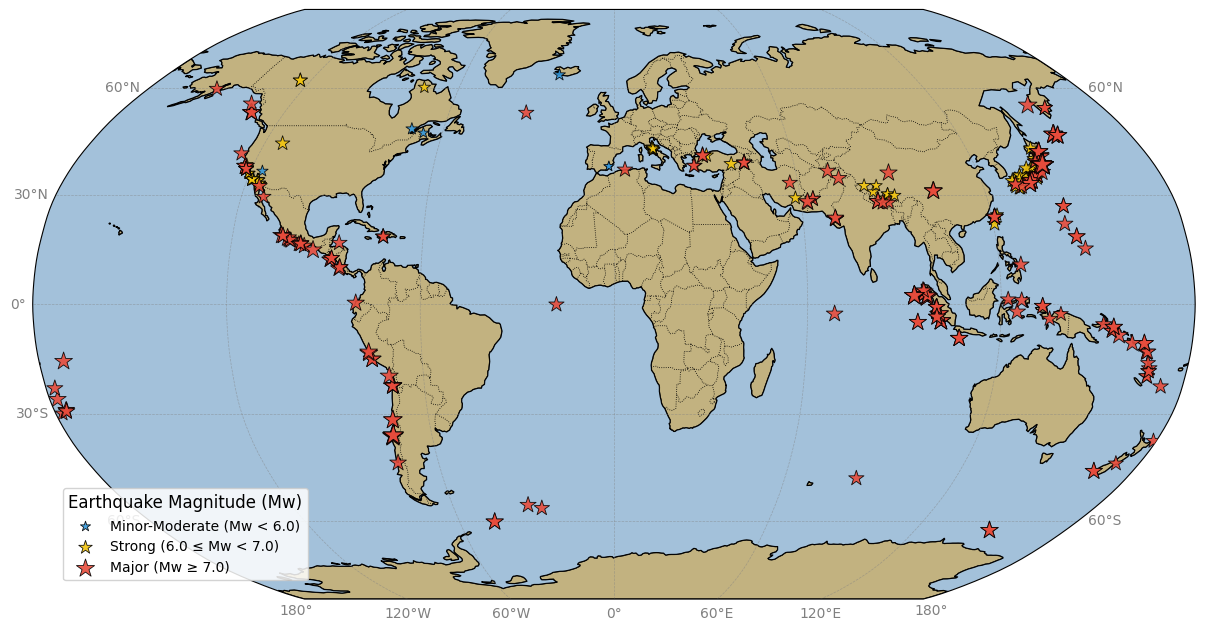

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# --- 1. Load and Prepare Data ---
try:
    df = pd.read_csv(r'./Dataset/extracted_dataset/non-multisegment/non-multisegment_input.csv')
except FileNotFoundError:
    print("Error: The specified CSV file was not found.")
    exit()

# --- 2. Categorize Earthquake Magnitudes ---
bins = [0, 5.9, 6.9, float('inf')]
labels = ['Minor-Moderate (Mw < 6.0)', 'Strong (6.0 ≤ Mw < 7.0)', 'Major (Mw ≥ 7.0)']
df['Mw_category'] = pd.cut(df['Mw'], bins=bins, labels=labels, right=False)

# --- 3. Define Aesthetics ---
color_map = {
    'Minor-Moderate (Mw < 6.0)': '#3498db',  # Blue
    'Strong (6.0 ≤ Mw < 7.0)': '#f1c40f',    # Yellow
    'Major (Mw ≥ 7.0)': '#e74c3c'            # Red
}

# --- 4. Create Map ---
fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson())
ax.set_global()

# --- 5. Add Earth-like Map Features ---
# Earthy colors: greenish-brown land, blue ocean
ax.add_feature(cfeature.LAND, zorder=0, edgecolor='black', facecolor='#c2b280')  # Earthy tan-green
ax.add_feature(cfeature.OCEAN, zorder=0, facecolor='#a3c1da')                     # Soft blue
ax.add_feature(cfeature.COASTLINE, zorder=1, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, zorder=1, linestyle=':', linewidth=0.6)

# Add subtle gridlines
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 10, 'color': 'gray'}
gl.ylabel_style = {'size': 10, 'color': 'gray'}

# --- 6. Plot Earthquake Data as Stars ---
legend_elements = []
for category in labels:
    subset = df[df['Mw_category'] == category]
    scatter = ax.scatter(subset['LON'], subset['LAT'],
                         s=subset['Mw']**2.5,       # marker size scales with magnitude
                         c=color_map[category],
                         label=category,
                         alpha=0.9,
                         marker='*',                # star marker
                         edgecolors='black',
                         linewidth=0.6,
                         transform=ccrs.PlateCarree(),
                         zorder=10)
    legend_elements.append(scatter)

# --- 7. Add Legend ---
legend = ax.legend(handles=legend_elements,
                   title='Earthquake Magnitude (Mw)',
                   loc='lower left',
                   bbox_to_anchor=(0.02, 0.02),
                   frameon=True,
                   fontsize=10,
                   title_fontsize=12)
legend.get_frame().set_facecolor('white')
legend.get_frame().set_alpha(0.85)

# --- 8. Save Map ---
plt.savefig('publication_earthquake_map.png', dpi=300, bbox_inches='tight', pad_inches=0.2)
plt.savefig('publication_earthquake_map.pdf', bbox_inches='tight', pad_inches=0.2)

print("Map has been saved as 'publication_earthquake_map.png' and 'publication_earthquake_map.pdf'")

plt.show()
